In [2]:
# Imports for all steps

import pandas as pd
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


# Step 1: Set up Crop availability 

In [3]:
# Load the region boundaries 
# Inputs
regions_gdf = gpd.read_file('../../data/processed/region_boundary.gpkg', layer='regions')
CROP_ENERGY_PATH = '../../data/processed/energy'
#Output
CROP_OUTPUT_PATH = '../../data/processed/energy/all_crops_GLEAM_region'

# List of crops
crops = [
    "wheat", "rice", "maize", "barley", "pearlmill", "smallmill", "sorghum", 
    "oth_cereal", "potato", "sweet_pot", "yams", "cassava", "oth_root", "bean", 
    "chickpea", "cowpea", "pigeonpea", "lentil", "oth_pulse", "soybean", "groundnut", 
    "coconut", "oilpalm", "sunflower", "rapeseed", "sesameseed", "oth_oil", 
    "sugarcane", "sugarbeet", "cotton", "oth_fibre",
    "banana", "plantain", "trop_fruit", "temp_fruit", 
    "vegetable", "rest_crop", "grassland"
]


In [4]:
def get_crop_energy_sums(regions_gdf, crops):
    """
    Calculate the sum of energy for each crop within each region.
    
    :param regions_gdf: GeoDataFrame of GLEAM regions.
    :param crops: List of crop names.
    :return: DataFrame with summed energy values for each crop across regions.
    """
    # Initialize an empty DataFrame with regions as columns
    crop_data = pd.DataFrame(columns=regions_gdf['Region'].unique())
    
    for crop in crops:
        energy_file = f"{CROP_ENERGY_PATH}/{crop}_energy.tif"
        crop_sums = []
        
        with rasterio.open(energy_file) as src:
            for region_name in crop_data.columns:
                region_geom = regions_gdf.loc[regions_gdf['Region'] == region_name, 'geometry'].values[0]
                out_image, _ = mask(src, [region_geom], crop=True, all_touched=True)
                sum_energy = np.nansum(out_image[out_image != src.nodata])
                crop_sums.append(sum_energy)
        
        crop_data.loc[crop] = crop_sums
    
    return crop_data


def plot_crop_with_regions(crop_name, regions_gdf):
    """
    Plot a crop energy raster overlayed with region boundaries.
    
    :param crop_name: Name of the crop.
    :param regions_gdf: GeoDataFrame of regions.
    """
    energy_file = f"../../data/processed/energy/{crop_name}_energy.tif"

    # Open and read the raster file
    with rasterio.open(energy_file) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        show(src, ax=ax)

        # Overlay the region boundaries
        regions_gdf.boundary.plot(ax=ax, edgecolor='red')

    plt.show()




CRS of regions GeoDataFrame: {'init': 'epsg:4326'}
CRS of crop raster: EPSG:4326


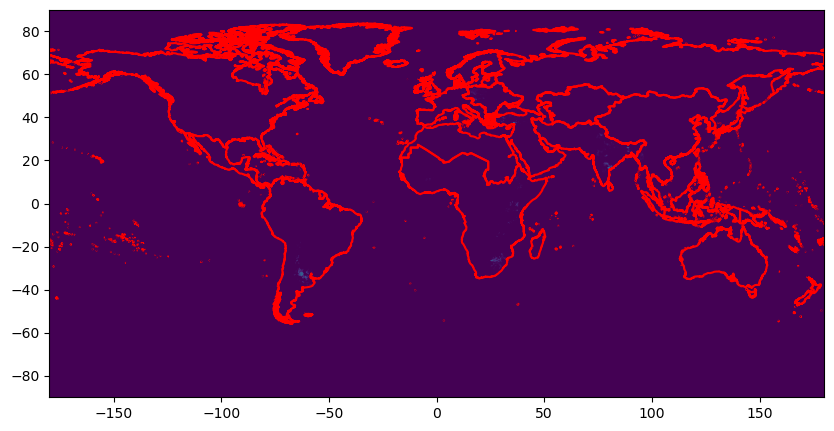

In [5]:
# Calculate energy sums
crop_energy_df = get_crop_energy_sums(regions_gdf, crops)

# Save the crop_energy_df DataFrame to a CSV file
crop_energy_df.to_csv(CROP_OUTPUT_PATH)

# Check the CRS
print("CRS of regions GeoDataFrame:", regions_gdf.crs)
with rasterio.open('../../data/processed/energy/Maize_energy.tif') as src:
    print("CRS of crop raster:", src.crs)

# Plotting example
plot_crop_with_regions('Maize', regions_gdf)

In [6]:
# Save the crop_energy_df DataFrame to a CSV file
crop_energy_df.to_csv(CROP_OUTPUT_PATH)

# Step 2: Set up animal availability and micronutrients

In [10]:
# Global constants for file paths
REGION_BOUNDARY_FILE = '../../data/processed/region_boundary.gpkg'
ANIMAL_ENERGY_PATH = '../../data/raw/GLW'
MACRONUTRIENT_FILEPATH = '../../data/processed/ruminant_macronutrient_requirement_table.csv'
MACRONUTRIENT_FILEPATH_FILLED = '../../data/processed/ruminant_macronutrient_requirement_table_filled.csv'

In [11]:

def get_animal_energy_sums(regions_gdf, animals, animal_codes):
    """
    Calculate the sum of energy for each animal within each region.

    :param regions_gdf: GeoDataFrame of regions.
    :param animals: List of animal names.
    :param animal_codes: Corresponding codes for the animals.
    :return: DataFrame with summed energy values for each animal across regions.
    """
    animal_data = pd.DataFrame(columns=regions_gdf['Region'].unique())
    
    for animal, code in zip(animals, animal_codes):
        energy_file = f"{ANIMAL_ENERGY_PATH}/{animal}_2010/5_{code}_2010_Da.tif"
        animal_sums = []
        
        with rasterio.open(energy_file) as src:
            for region_name in animal_data.columns:
                region_geom = regions_gdf.loc[regions_gdf['Region'] == region_name, 'geometry'].values[0]
                out_image, _ = mask(src, [region_geom], crop=True, all_touched=True)
                sum_energy = np.nansum(out_image[out_image != src.nodata])
                animal_sums.append(sum_energy)
        
        animal_data.loc[animal] = animal_sums
    
    return animal_data




In [12]:
# Get animal counts

# Load the region boundaries
regions_gdf = gpd.read_file(REGION_BOUNDARY_FILE, layer='regions')

# List of animals and their codes
animals = ["buffalo", "cattle", "goats", "sheep"]
animal_codes = ["Bf", "Ct", "Gt", "Sh"]

animal_count_df = get_animal_energy_sums(regions_gdf, animals, animal_codes)

# Clean up up ruminant macronutrient file

# Modify animal count DataFrame
animal_count_df.loc['Dairy cattle'] = animal_count_df.loc['cattle'] * 0.2
animal_count_df.loc['Beef cattle'] = animal_count_df.loc['cattle'] * 0.8
animal_count_df.rename(index={'goats': 'Goat', 'buffalo': 'Buffalo', 'sheep':'Sheep'}, inplace=True)
animal_count_df.drop('cattle', inplace=True)

# Load and process macronutrients data
macronutrients_full = pd.read_csv(MACRONUTRIENT_FILEPATH, keep_default_na=False)
region_name_mapping = {
    'Latin America and the Caribbean': 'Central & South America',
    'East and Southeast Asia': 'East Asia',
    'Russia': 'Russian Federation',
    'Sub-saharan Africa': 'Sub-Saharan Africa',
    'Near East and North Africa': 'West Asia & Northern Africa'
}
macronutrients_full['region_name'] = macronutrients_full['region_name'].map(region_name_mapping).fillna(macronutrients_full['region_name'])

# Save the modified dataframe
macronutrients_full.to_csv(MACRONUTRIENT_FILEPATH_FILLED, index=False)

In [13]:
macronutrients_full.head()

,species,region_code,region_name,adult_female_weight,adult_male_weight,child_weight,adult_female_protein_req,adult_male_protein_req,child_protein_req,adult_female_energy_req,adult_male_energy_req,child_energy_req,dairy_cattle_ratio,adult_female_fraction,adult_male_fraction,child_fraction
0,Sheep,NA,North America,82.0,111.0,4.3,0.124263,0.150567,0.014921,5.061403,5.656573,1.342821,0.205436,0.49,0.01,0.5
1,Sheep,RUS,Russian Federation,50.0,103.0,3.5,0.095238,0.143311,0.013832,3.680114,5.554747,1.101823,0.472624,0.49,0.01,0.5
2,Sheep,WE,Western Europe,68.0,86.0,4.5,0.111565,0.127891,0.015193,4.550627,5.180614,1.402440,0.418536,0.49,0.01,0.5
3,Sheep,EE,Eastern Europe,50.0,103.0,3.5,0.095238,0.143311,0.013832,3.680114,5.554747,1.101823,0.480588,0.49,0.01,0.5
4,Sheep,NENA,West Asia & Northern Africa,45.0,65.0,3.7,0.090703,0.108844,0.014104,3.395619,4.422245,1.162451,0.514362,0.49,0.01,0.5


# Step 3 - Define the animal Priority and Requirements

In [14]:
# Global constants for file paths
ENERGY_REQ_FILEPATH = '../../data/processed/ruminant_macronutrient_requirement_table_filled.csv'
OUTPUT_FILEPATH = '../../data/processed/ruminant_macronutrient_requirement_table_filled_total.csv'

In [15]:
# Read the energy requirements DataFrame
energy_req_df = pd.read_csv(ENERGY_REQ_FILEPATH, keep_default_na=False)

# Reset the index of animal count DataFrame and rename the column
animal_count_reset = animal_count_df.reset_index().rename(columns={'index': 'species'})

# Melt the DataFrame to reformat it
animal_count_melted = animal_count_reset.melt(id_vars=['species'], var_name='region_name', value_name='count')

# Merge the DataFrames on 'region_name' and 'species'
combined_energy_df = pd.merge(energy_req_df, animal_count_melted, on=['region_name', 'species'])

# Calculate individual energy requirements
combined_energy_df['adult_female_energy'] = combined_energy_df['adult_female_energy_req'] * combined_energy_df['adult_female_weight']
combined_energy_df['adult_male_energy'] = combined_energy_df['adult_male_energy_req'] * combined_energy_df['adult_male_weight']
combined_energy_df['child_energy'] = combined_energy_df['child_energy_req'] * combined_energy_df['child_weight']

# Weight by the fractions and multiply by the count
combined_energy_df['total_female_energy'] = combined_energy_df['adult_female_energy'] * combined_energy_df['adult_female_fraction'] * combined_energy_df['count']
combined_energy_df['total_male_energy'] = combined_energy_df['adult_male_energy'] * combined_energy_df['adult_male_fraction'] * combined_energy_df['count']
combined_energy_df['total_child_energy'] = combined_energy_df['child_energy'] * combined_energy_df['child_fraction'] * combined_energy_df['count']

# Calculate the total energy requirement
combined_energy_df['total_energy_requirement'] = combined_energy_df['total_female_energy'] + combined_energy_df['total_male_energy'] + combined_energy_df['total_child_energy']

# Save the modified DataFrame to a CSV file
combined_energy_df.to_csv(OUTPUT_FILEPATH, index=False)

# Step 4 - Feeding Algorithm

## Constants and File paths

In [16]:
# Global constants
CROP_SUITABILITY_PATH = 'combined_ruminant_data.csv'
MACRONUTRIENT_FILEPATH = '../../data/processed/ruminant_macronutrient_requirement_table_filled_total.csv'
CROP_MACRO_LOOKUP_PATH = '../../data/processed/lookup_tables/spam_crop_macro_lookup.csv'
CROP_AVAILABILITY_PATH = '../../data/processed/energy/all_crops_GLEAM_region'

REGIONS = [
    'Central & South America', 'East Asia', 'Eastern Europe',
    'North America', 'Oceania', 'Russian Federation', 'South Asia',
    'Sub-Saharan Africa', 'West Asia & Northern Africa',
    'Western Europe'
]

# Potentially alter: 
ANIMAL_PRIORITIES = ["Dairy cattle", "Goat", "Sheep", "Beef cattle", "Buffalo"]
MAX_DAYS = 500

# Read the CSV files
macronutrients_full = pd.read_csv(MACRONUTRIENT_FILEPATH, keep_default_na=False)
crop_macro_lookup = pd.read_csv(CROP_MACRO_LOOKUP_PATH)
crop_availability = pd.read_csv(CROP_AVAILABILITY_PATH, index_col=0)


In [17]:

def get_efficiency(animal, region, macronutrients, crop_macro_lookup):
    """
    Calculate the efficiency of how well each animal uses each crop energy for a given region.
    :param animal: The animal species.
    :param region: The geographical region.
    :param macronutrients: DataFrame containing macronutrient data.
    :param crop_macro_lookup: DataFrame containing crop macro data.
    :return: DataFrame of crop priorities or None if data is not available.
    """
    macronutrients = macronutrients[(macronutrients['species'] == animal) & (macronutrients['region_name'] == region)].copy()

    if macronutrients.empty:
        return None

    # Calculate the average adult weight
    macronutrients['total_adult_population'] = macronutrients['adult_female_fraction'] + macronutrients['adult_male_fraction']
    macronutrients['avg_adult_weight'] = (
        (macronutrients['adult_female_weight'] * macronutrients['adult_female_fraction']) + 
        (macronutrients['adult_male_weight'] * macronutrients['adult_male_fraction'])
    ) / macronutrients['total_adult_population']

    # Calculate total energy requirement for this animal in this region
    total_energy_req = (macronutrients['adult_female_energy_req'] * macronutrients['adult_female_fraction'] +
                        macronutrients['adult_male_energy_req'] * macronutrients['adult_male_fraction']).sum()

    if total_energy_req <= 0:
        print(f"Invalid total energy requirement for {animal} in {region}")
        return None

    # Calculate VDMI, energy intake, and percentage of energy requirement for each crop
    crop_macro_lookup = crop_macro_lookup.copy()
    if animal == 'Beef cattle' or animal == 'Dairy cattle' or animal == 'Buffalo':
        crop_macro_lookup['vmdi'] = macronutrients['avg_adult_weight'].iloc[0] * 1 / crop_macro_lookup['ndf']
    else:
        crop_macro_lookup['vmdi'] = macronutrients['avg_adult_weight'].iloc[0] * 1.2 / crop_macro_lookup['ndf']
    crop_macro_lookup['energy_intake'] = crop_macro_lookup['vmdi'] * crop_macro_lookup['ruminant_me']
    crop_macro_lookup['percent_energy_req'] = (crop_macro_lookup['energy_intake'] / total_energy_req) * 100

    # Sort crops by their percentage of energy requirement for this animal
    crop_priority = crop_macro_lookup[['spam_crop_long', 'percent_energy_req']]
    crop_priority = crop_priority.sort_values(by='percent_energy_req', ascending=False)

    return crop_priority

def get_crop_energy_availability(region, crop_energy_availability):
    """
    Get the crop energy availability for a given region.
    :param region: The geographical region.
    :param crop_energy_availability: DataFrame containing crop energy availability data.
    :return: Dictionary of crop energy availability for the region.
    """
    return crop_energy_availability[region].to_dict()

def get_animal_energy_requirement(animal, region, animal_energy_requirements):
    """
    Get the total energy requirement for a specific animal in a given region.
    :param animal: The animal species.
    :param region: The geographical region.
    :param animal_energy_requirements: DataFrame containing animal energy requirements.
    :return: Total energy requirement for the animal or None if not available.
    """
    animal_energy_req_df = animal_energy_requirements.loc[
        (animal_energy_requirements['species'] == animal) & 
        (animal_energy_requirements['region_name'] == region),
        'total_energy_req'
    ]
    return animal_energy_req_df.values[0] if not animal_energy_req_df.empty else None

# Function to calculate the number of days animals can be sustained with available crops
def calculate_days_sustained(max_days, regions, animal_priorities, macronutrients_full, crop_macro_lookup, crop_availability):
    """
    Calculate the number of days animals in each region can be sustained with available crops.
    :param max_days: Maximum number of days for the simulation.
    :param regions: List of regions.
    :param animal_priorities: List of animal priorities.
    :param macronutrients_full: DataFrame with macronutrient data/requirements for animals.
    :param crop_macro_lookup: DataFrame with crop macro data.
    :param crop_availability: DataFrame with crop energy data.
    :return: Dictionary of days sustained for each animal in each region.
    """
    animal_crop_priorities = {region: {} for region in regions}
    for region in regions:
        for animal in animal_priorities:
            efficiency = get_efficiency(animal, region, macronutrients_full, crop_macro_lookup)
            if efficiency is not None:
                animal_crop_priorities[region][animal] = efficiency

    days_sustained = {region: {animal: 0 for animal in animal_priorities} for region in regions}
    animals_fed = {region: {} for region in regions}

    for day in range(1, max_days + 1):
        crop_energy_availability = crop_availability.copy()
        animal_energy_requirements = macronutrients_full.copy()
        animal_energy_requirements['total_energy_req'] = animal_energy_requirements['total_energy_requirement'] * day

        for region in regions:
            crop_bucket = get_crop_energy_availability(region, crop_energy_availability)

            for animal in animal_priorities:
                if animal in animal_crop_priorities[region]:
                    prioritized_crops = animal_crop_priorities[region][animal]
                    animal_total_energy_req = get_animal_energy_requirement(animal, region, animal_energy_requirements)
                    animal_energy_remaining = animal_total_energy_req

                    for _, row in prioritized_crops.iterrows():
                        crop_name = row['spam_crop_long'].lower()
                        if crop_name in crop_bucket and row['percent_energy_req'] >= 100:
                            crop_energy_available = crop_bucket[crop_name]
                            max_energy_allocation = min(crop_energy_available, animal_energy_remaining)
                            crop_bucket[crop_name] -= max_energy_allocation
                            animal_energy_remaining -= max_energy_allocation

                            if animal_energy_remaining <= 0:
                                animals_fed[region].setdefault(animal, 0)
                                animals_fed[region][animal] += 1
                                break

    return animals_fed

In [18]:


# Output the results
animals_fed = calculate_days_sustained(MAX_DAYS, REGIONS, ANIMAL_PRIORITIES, macronutrients_full, crop_macro_lookup, crop_availability)
print("Days Animals are Fed in Each Region:")
for region, fed_counts in animals_fed.items():
    print(f"{region}: {fed_counts}")



Days Animals are Fed in Each Region:
Central & South America: {'Dairy cattle': 18, 'Goat': 18, 'Sheep': 17, 'Beef cattle': 2, 'Buffalo': 2}
East Asia: {'Dairy cattle': 101, 'Goat': 90, 'Sheep': 82, 'Beef cattle': 5, 'Buffalo': 4}
Eastern Europe: {'Dairy cattle': 7, 'Goat': 7, 'Sheep': 7, 'Beef cattle': 1, 'Buffalo': 1}
North America: {'Dairy cattle': 57, 'Goat': 57, 'Sheep': 57, 'Beef cattle': 3, 'Buffalo': 3}
Oceania: {'Dairy cattle': 274, 'Goat': 268, 'Sheep': 132, 'Beef cattle': 13, 'Buffalo': 13}
Russian Federation: {'Dairy cattle': 105, 'Goat': 104, 'Sheep': 97, 'Beef cattle': 14, 'Buffalo': 14}
South Asia: {'Dairy cattle': 6, 'Goat': 6, 'Sheep': 6, 'Beef cattle': 2}
Sub-Saharan Africa: {'Dairy cattle': 64, 'Goat': 61, 'Sheep': 59, 'Beef cattle': 24, 'Buffalo': 24}
West Asia & Northern Africa: {'Dairy cattle': 102, 'Goat': 96, 'Sheep': 78, 'Beef cattle': 17, 'Buffalo': 15}
Western Europe: {'Dairy cattle': 9, 'Goat': 9, 'Sheep': 8, 'Beef cattle': 1, 'Buffalo': 1}


In [19]:
pd.DataFrame(animals_fed).sum().sum()

2161.0